In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
img_escura = files.upload()

Saving artorias.jpeg to artorias.jpeg


# Imagem escura

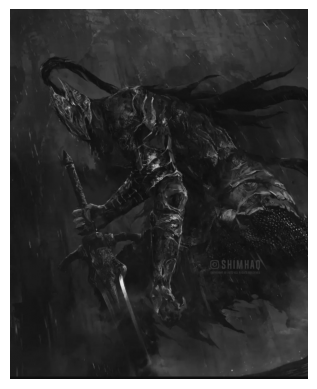

In [9]:
artorias = cv2.imread("artorias.jpeg", cv2.IMREAD_COLOR_RGB)
plt.imshow(artorias)
artorias_gray = cv2.cvtColor(artorias, cv2.COLOR_RGB2GRAY)
plt.axis("off")
plt.imshow(artorias_gray, cmap="gray")

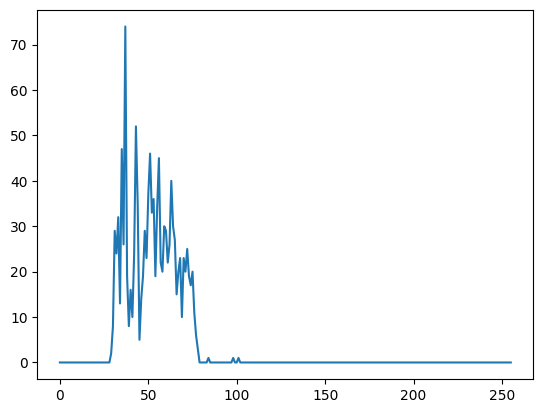

In [15]:
artorias_hist = cv2.calcHist(artorias_gray, [0], None, [256], [0,256])
plt.plot(artorias_hist)

Como a imagem é bem escura, por conta de ter muitos pixels próximo de 0, a redistribuição de intensidade dos pixels é uma boa candidata para melhorar a imagem.

## Equalizando o artorias

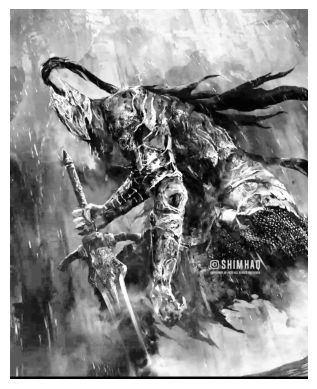

In [13]:
artorias_gray_equalizado = cv2.equalizeHist(artorias_gray)
plt.axis("off")
plt.imshow(artorias_gray_equalizado, cmap="gray")

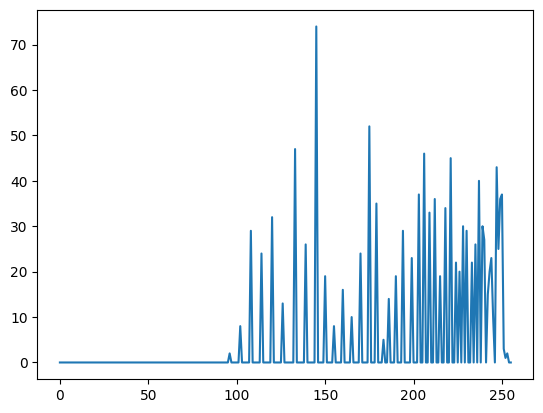

In [14]:
artorias_hist_equalizado = cv2.calcHist(artorias_gray_equalizado, [0], None, [256], [0,256])
plt.plot(artorias_hist_equalizado)

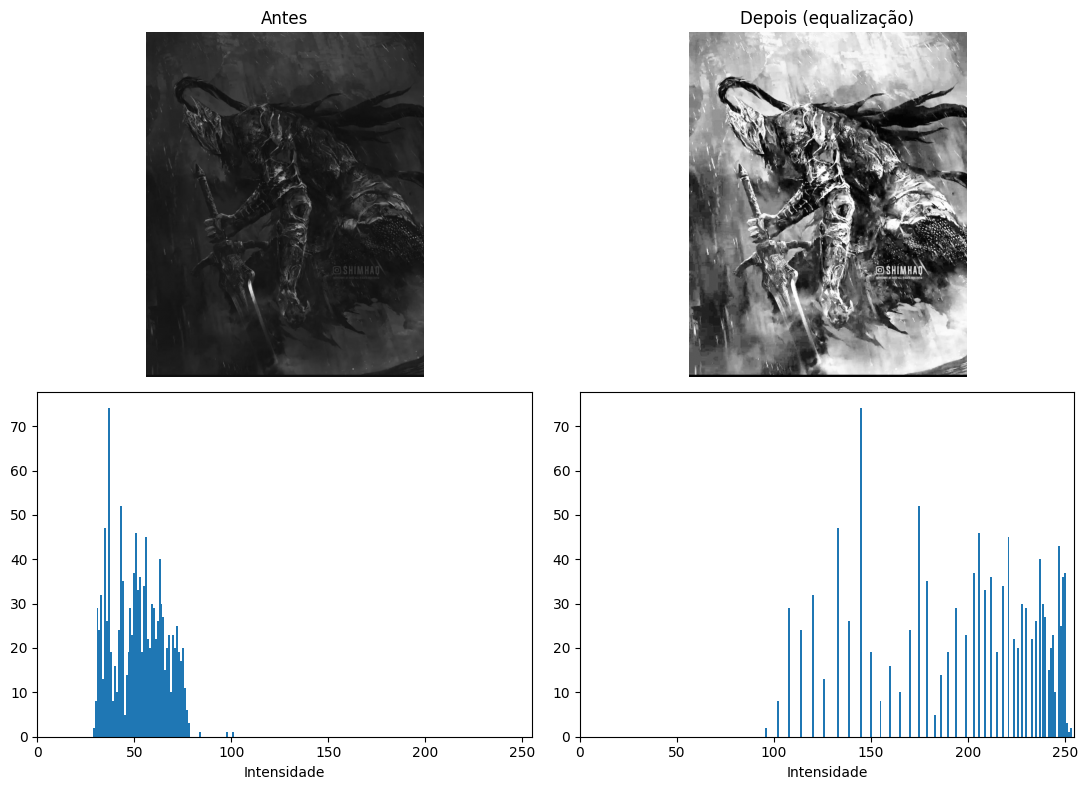

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

ax[0, 0].imshow(artorias_gray, cmap="gray", vmin=0, vmax=255)
ax[0, 0].set_title("Antes")
ax[0, 0].set_axis_off()

ax[0, 1].imshow(artorias_gray_equalizado, cmap="gray", vmin=0, vmax=255)
ax[0, 1].set_title("Depois (equalização)")
ax[0, 1].set_axis_off()

ax[1, 0].bar(range(256), artorias_hist, width=1.0)
ax[1, 0].set_xlim(0, 255)
ax[1, 0].set_xlabel("Intensidade")

ax[1, 1].bar(range(256), artorias_hist_equalizado, width=1.0)
ax[1, 1].set_xlim(0, 255)
ax[1, 1].set_xlabel("Intensidade")

plt.tight_layout()
plt.show()

# Imagem Saturada

In [17]:
img_saturada = files.upload()

Saving maul.jpeg to maul.jpeg


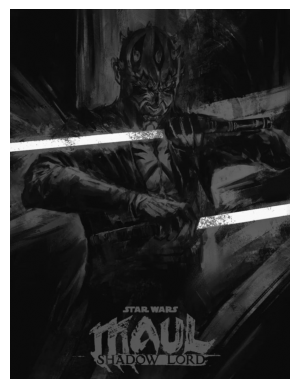

In [18]:
maul = cv2.imread("maul.jpeg", cv2.IMREAD_COLOR_RGB)
plt.imshow(maul)
maul_gray = cv2.cvtColor(maul, cv2.COLOR_RGB2GRAY)
plt.axis("off")
plt.imshow(maul_gray, cmap="gray")

In [20]:
maul.shape

(1599, 1210, 3)

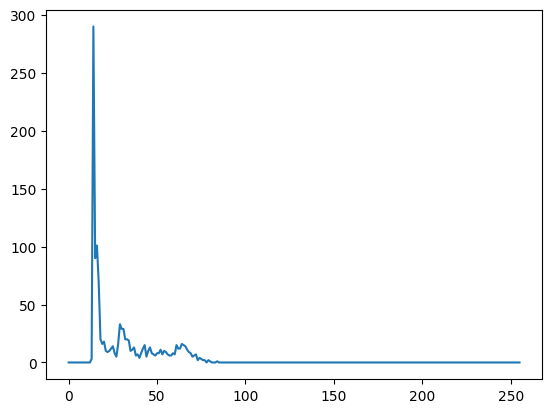

In [19]:
maul_hist = cv2.calcHist(maul_gray, [0], None, [256], [0,256])
plt.plot(maul_hist)

## Expandindo contraste

In [24]:
L, H = np.percentile(maul_gray, [2,98])
print(f"L = {L:.0f}, H = {H:.0f}")

L = 14, H = 148


In [25]:
maul_expandido = np.clip(maul_gray.astype(np.float32), L, H)
maul_expandido = (maul_expandido - L) * (255 / (H - L))
maul_expandido = np.round(maul_expandido).astype(np.uint8)

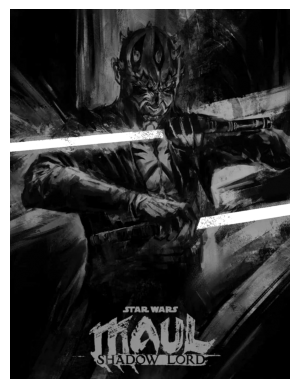

In [28]:
plt.axis("off")
plt.imshow(maul_expandido, cmap="gray")

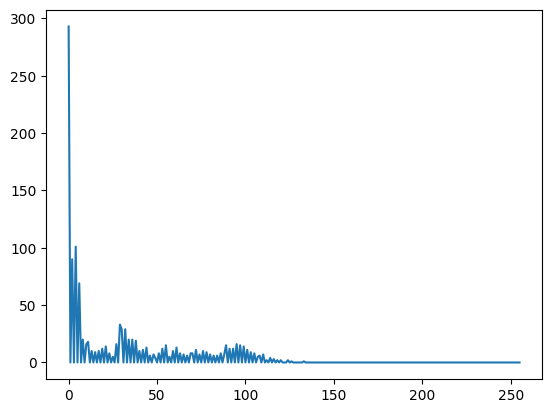

In [26]:
maul_expandido_hist = cv2.calcHist(maul_expandido, [0], None, [256], [0,256])
plt.plot(maul_expandido_hist)

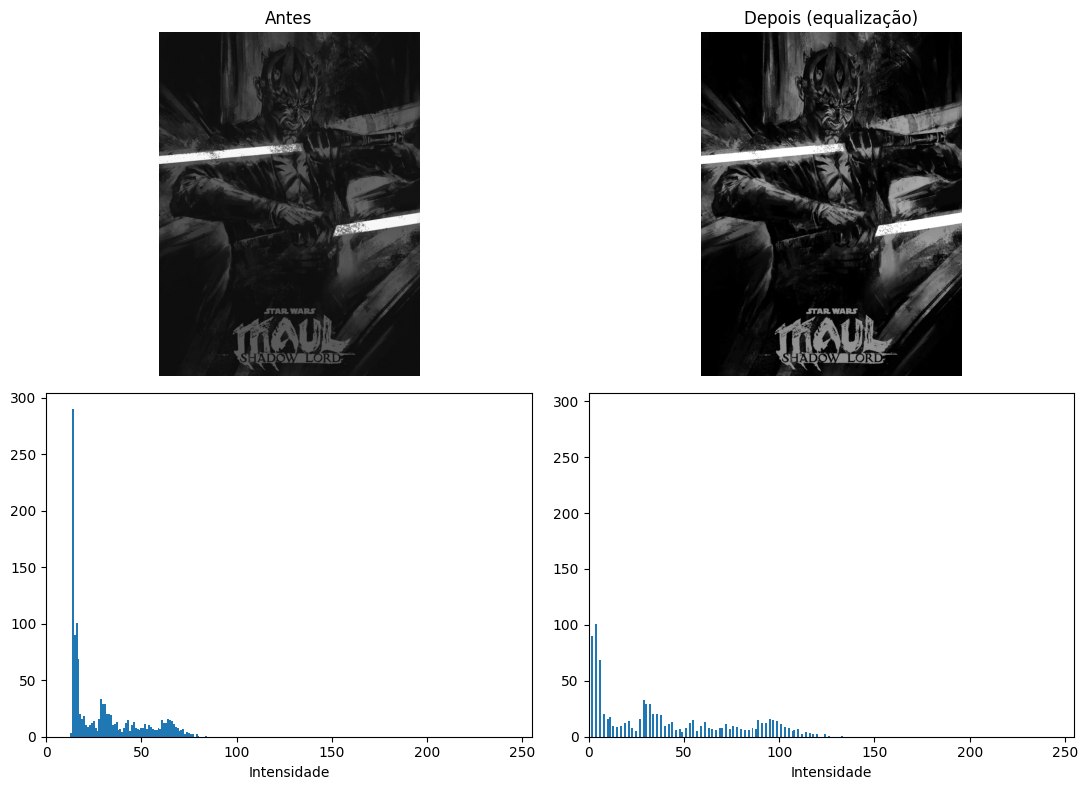

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

ax[0, 0].imshow(maul_gray, cmap="gray", vmin=0, vmax=255)
ax[0, 0].set_title("Antes")
ax[0, 0].set_axis_off()

ax[0, 1].imshow(maul_expandido, cmap="gray", vmin=0, vmax=255)
ax[0, 1].set_title("Depois (equalização)")
ax[0, 1].set_axis_off()

ax[1, 0].bar(range(256), maul_hist, width=1.0)
ax[1, 0].set_xlim(0, 255)
ax[1, 0].set_xlabel("Intensidade")

ax[1, 1].bar(range(256), maul_expandido_hist, width=1.0)
ax[1, 1].set_xlim(0, 255)
ax[1, 1].set_xlabel("Intensidade")

plt.tight_layout()
plt.show()

# Imagem bem exposta

In [29]:
img_bem_exposta = files.upload()

Saving tarnished.jpeg to tarnished.jpeg


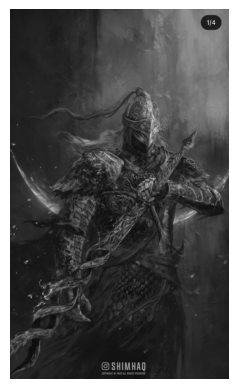

In [30]:
tarnished = cv2.imread("tarnished.jpeg", cv2.IMREAD_COLOR_RGB)
plt.imshow(tarnished)
tarnished_gray = cv2.cvtColor(tarnished, cv2.COLOR_RGB2GRAY)
plt.axis("off")
plt.imshow(tarnished_gray, cmap="gray")

##

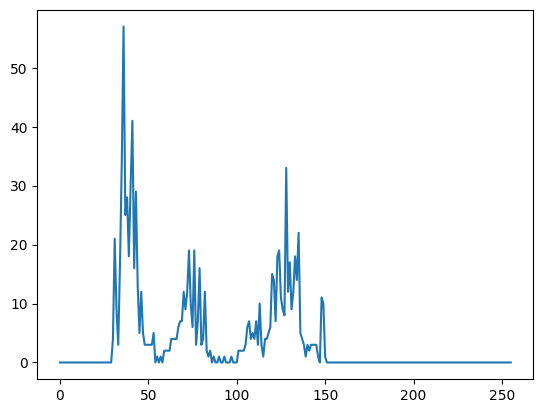

In [31]:
tarnished_hist = cv2.calcHist(tarnished_gray, [0], None, [256], [0,256])
plt.plot(tarnished_hist)

## Alterando o gamma

o valor abaixo para o gama, foi definido após ser testados valores em uma escala de 0 a 1, em que a imagem não apresentou nenhuma piora de qualidade visual.

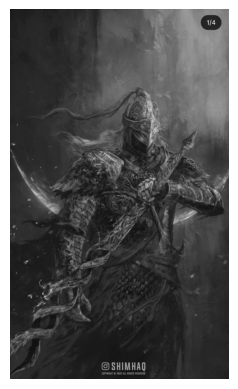

In [39]:
gamma = 0.9

tabela_conversão = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
tarnished_gamma = cv2.LUT(tarnished_gray, tabela_conversão)

plt.axis("off")
plt.imshow(tarnished_gamma, cmap="gray")

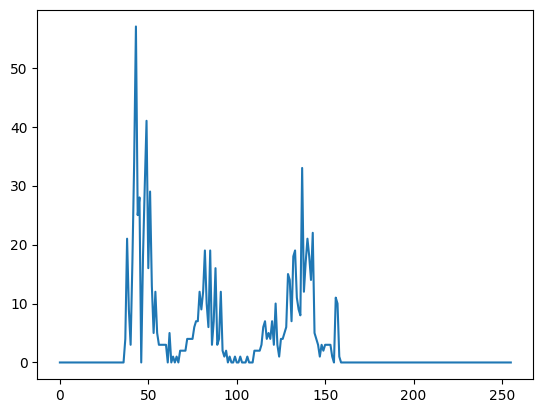

In [40]:
tarnished_gamma_hist = cv2.calcHist(tarnished_gamma, [0], None, [256], [0,256])
plt.plot(tarnished_gamma_hist)

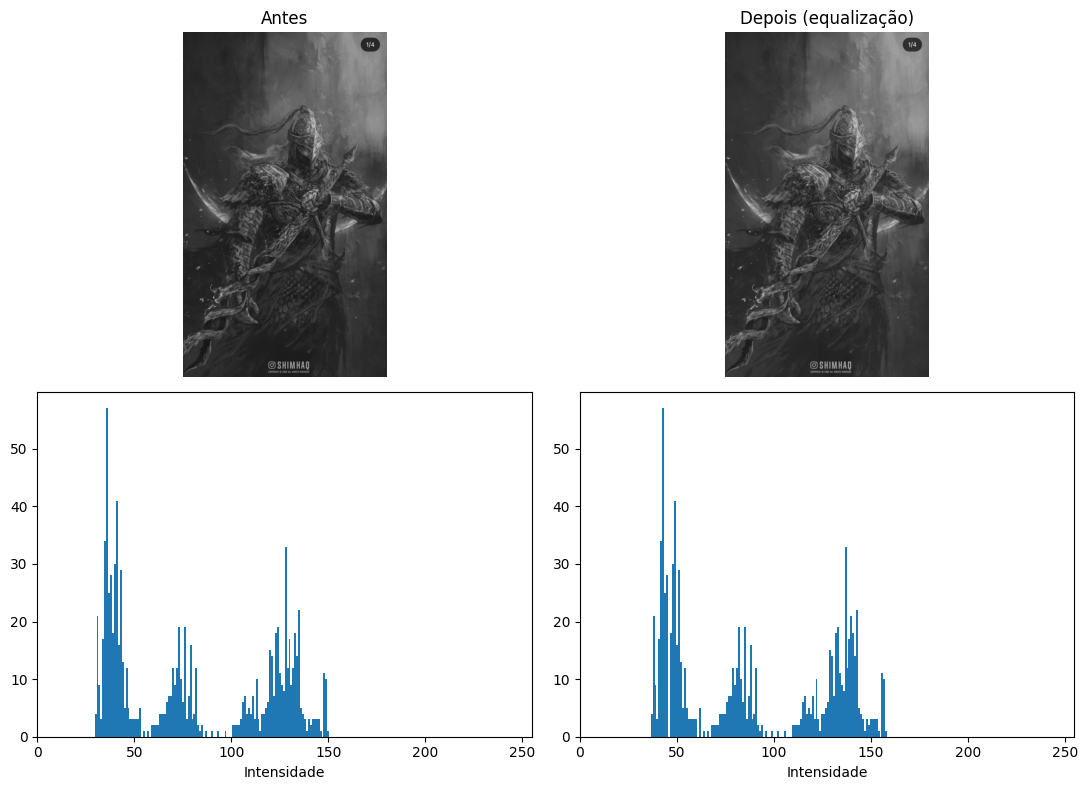

In [41]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

ax[0, 0].imshow(tarnished_gray, cmap="gray", vmin=0, vmax=255)
ax[0, 0].set_title("Antes")
ax[0, 0].set_axis_off()

ax[0, 1].imshow(tarnished_gamma, cmap="gray", vmin=0, vmax=255)
ax[0, 1].set_title("Depois (equalização)")
ax[0, 1].set_axis_off()

ax[1, 0].bar(range(256), tarnished_hist, width=1.0)
ax[1, 0].set_xlim(0, 255)
ax[1, 0].set_xlabel("Intensidade")

ax[1, 1].bar(range(256), tarnished_gamma_hist, width=1.0)
ax[1, 1].set_xlim(0, 255)
ax[1, 1].set_xlabel("Intensidade")

plt.tight_layout()
plt.show()

A imagem que já era boa, foi a que menos se beneficiou de operações para melhorar a visualização dela (correção gamma). Pelo que é observável a partir do histograma, os intervalos que mais acumulam pixes se deslocaram mas pouco. E como é possível observar nas imagens, a visualização não teve nenhum impacto significativo.